In [6]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250922-one-away-multimutant-benchmark',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'GRB2_HUMAN_Faure_2021', 'PABP_YEAST_Melamed_2013', 'SPG1_STRSG_Olson_2014'}


In [7]:
round_metrics_df.columns

Index(['dms_id', 'config_name', 'sim_num', 'variant_pool_size',
       'best_activity_this_round', 'best_percentile_this_round',
       'best_activity_so_far', 'normalized_best_activity_so_far',
       'best_percentile_so_far', 'round_num', 'model_spearman', 'misc',
       'held_out_activity_spearman', 'held_out_batch_1pct',
       'held_out_1pct_recall', 'held_out_1pct_recall_slate',
       'held_out_1pct_auc', 'held_out_batch_10pct', 'held_out_10pct_recall',
       'held_out_10pct_recall_slate', 'held_out_10pct_auc',
       'zero_shot_debug_info', 'few_shot_debug_info', 'dms_shortname'],
      dtype='object')

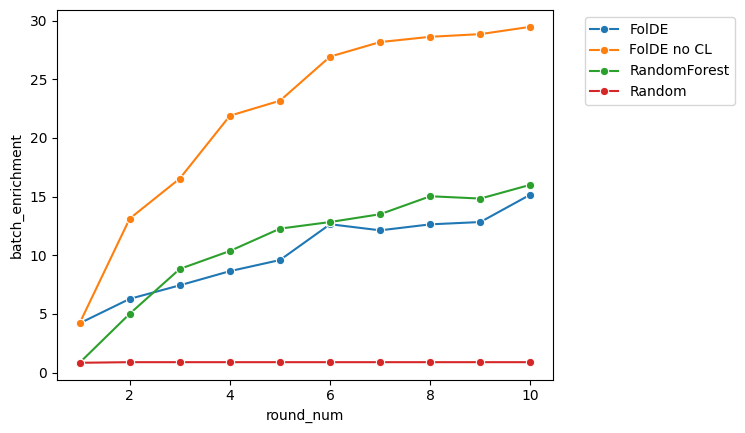

In [21]:
round_metrics_df['enrichment'] = (round_metrics_df.held_out_1pct_recall / 0.01 + round_metrics_df.held_out_10pct_recall / 0.10) / 2.0
round_metrics_df['enrichment_slate'] = (round_metrics_df.held_out_1pct_recall_slate / 0.01 + round_metrics_df.held_out_10pct_recall_slate / 0.10) / 2.0
round_metrics_df['batch_enrichment'] = (round_metrics_df.held_out_batch_1pct / 0.01 + round_metrics_df.held_out_batch_10pct / 0.10) / 2.0

# Multimutant & Test Benchmarks
CONFIG_RENAMES = {
    'FolDE-base': 'FolDE',
    'FolDE-no-constantliar': 'FolDE no CL',
    'RandomToRandomForest-base': 'RandomForest',
    'Random': 'Random',
}
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_RENAMES.keys())].reset_index()
plot_df['config_name'] = plot_df.config_name.map(CONFIG_RENAMES)
plot_df['inverse_best_percentile_so_far'] = 1 - plot_df['best_percentile_so_far']

for k, v in CONFIG_RENAMES.items():
    assert v in plot_df.config_name.unique(), f'{v} not found, only {plot_df.config_name.unique()}'

plt.figure()
ax = sns.lineplot(
    data=plot_df,#[plot_df.dms_id != 'ANCSZ_Hobbs_2022'].reset_index(),
    y='batch_enrichment',
    x='round_num',
    hue='config_name',
    # style='dms_id',
    errorbar=None,
    marker='o',
    hue_order=list(CONFIG_RENAMES.values()),
)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
